In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [20]:
np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
})

data.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
0,1,58,Female,164,175,234,77
1,2,71,Female,176,70,244,93
2,3,48,Female,103,115,207,77
3,4,34,Male,123,157,201,99
4,5,62,Female,177,91,210,90


In [21]:
data.info()
print(data.isnull().sum())
print("Duplicates:", data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB
Patient_ID        0
Age               0
Gender            0
Blood_Pressure    0
Sugar_Level       0
Cholesterol       0
Heart_Rate        0
dtype: int64
Duplicates: 0


In [22]:
data.describe()
print("Median:\n", data.median(numeric_only=True))
print("Mode:\n", data.mode().iloc[0])
print("Standard Deviation:\n", data.std(numeric_only=True))

Median:
 Patient_ID        5000.5
Age                 50.0
Blood_Pressure     130.0
Sugar_Level        136.0
Cholesterol        224.0
Heart_Rate          90.0
dtype: float64
Mode:
 Patient_ID            1
Age                73.0
Gender             Male
Blood_Pressure     94.0
Sugar_Level       156.0
Cholesterol       159.0
Heart_Rate         76.0
Name: 0, dtype: object
Standard Deviation:
 Patient_ID        2886.895680
Age                 17.588957
Blood_Pressure      29.138093
Sugar_Level         37.843946
Cholesterol         43.604943
Heart_Rate          17.483803
dtype: float64


In [23]:
def classify_risk(row):
    if (row["Blood_Pressure"] > 140 or
        row["Sugar_Level"] > 160 or
        row["Cholesterol"] > 240):
        return "High"
    elif (row["Blood_Pressure"] > 120 or
          row["Sugar_Level"] > 130 or
          row["Cholesterol"] > 200):
        return "Medium"
    else:
        return "Low"

data["Risk_Level"] = data.apply(classify_risk, axis=1)

data["Risk_Level"].value_counts()

,count
Risk_Level,
High,7463
Medium,1919
Low,618


In [24]:
high_risk_patients = data[data["Risk_Level"] == "High"]
print("Number of High Risk Patients:", len(high_risk_patients))
high_risk_patients.head()

Number of High Risk Patients: 7463


,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
0,1,58,Female,164,175,234,77,High
1,2,71,Female,176,70,244,93,High
4,5,62,Female,177,91,210,90,High
6,7,80,Female,88,199,179,79,High
9,10,77,Female,109,115,282,69,High


In [25]:
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ["20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
data["Age_Group"] = pd.cut(data["Age"], bins=bins, labels=labels)
data.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level,Age_Group
0,1,58,Female,164,175,234,77,High,50-60
1,2,71,Female,176,70,244,93,High,70-80
2,3,48,Female,103,115,207,77,Medium,40-50
3,4,34,Male,123,157,201,99,Medium,30-40
4,5,62,Female,177,91,210,90,High,60-70


In [26]:
age_risk = pd.crosstab(data["Age_Group"], data["Risk_Level"])
print(age_risk)

Risk_Level  High  Low  Medium
Age_Group                    
20-30       1183   84     299
30-40       1268   83     308
40-50       1221  111     318
50-60       1207  114     315
60-70       1208  106     322
70-80       1255  108     337


In [27]:
gender_risk = pd.crosstab(data["Gender"], data["Risk_Level"])
print(gender_risk)

Risk_Level  High  Low  Medium
Gender                       
Female      3678  289    1008
Male        3785  329     911


In [28]:
correlation = data.corr(numeric_only=True)
print(correlation)

                Patient_ID       Age  Blood_Pressure  Sugar_Level  \
Patient_ID        1.000000 -0.000225        0.009836     0.012334   
Age              -0.000225  1.000000       -0.008542    -0.001011   
Blood_Pressure    0.009836 -0.008542        1.000000    -0.018940   
Sugar_Level       0.012334 -0.001011       -0.018940     1.000000   
Cholesterol       0.007917 -0.015871        0.006170    -0.006722   
Heart_Rate       -0.002617  0.000218        0.004923     0.011292   

                Cholesterol  Heart_Rate  
Patient_ID         0.007917   -0.002617  
Age               -0.015871    0.000218  
Blood_Pressure     0.006170    0.004923  
Sugar_Level       -0.006722    0.011292  
Cholesterol        1.000000    0.004685  
Heart_Rate         0.004685    1.000000  


Bar chart

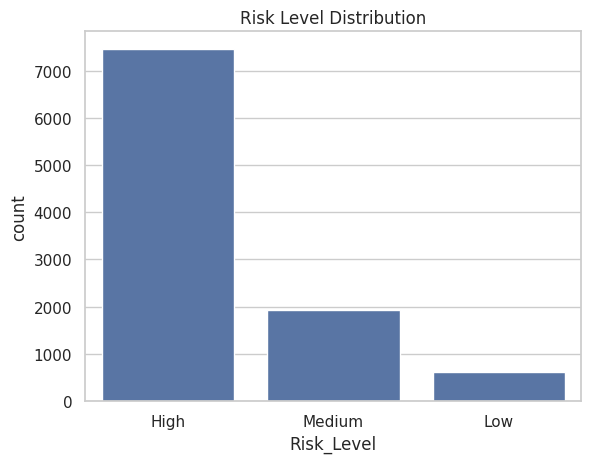

In [29]:
sns.countplot(x="Risk_Level", data=data)
plt.title("Risk Level Distribution")
plt.show()

Pie chart

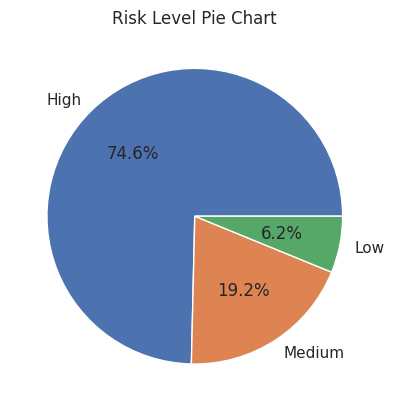

In [30]:
data["Risk_Level"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Risk Level Pie Chart")
plt.ylabel("")
plt.show()

Histogram

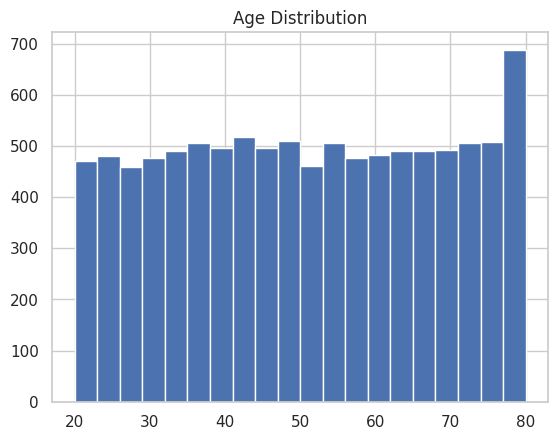

In [31]:
data["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.show()

Scatter plot

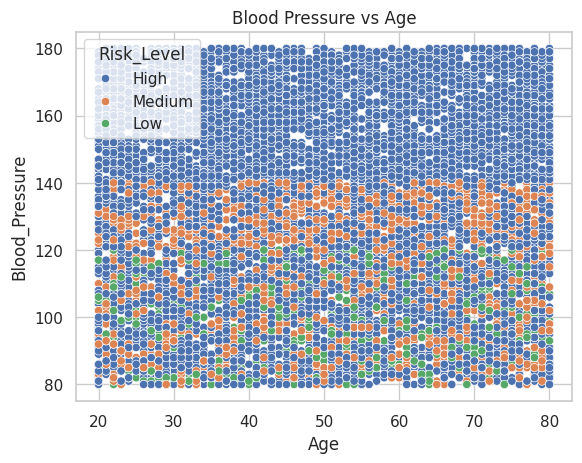

In [32]:
sns.scatterplot(x="Age", y="Blood_Pressure", hue="Risk_Level", data=data)
plt.title("Blood Pressure vs Age")
plt.show()

Box plot

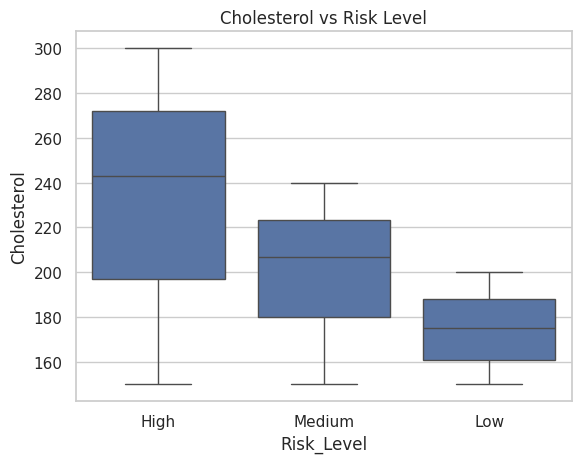

In [33]:
sns.boxplot(x="Risk_Level", y="Cholesterol", data=data)
plt.title("Cholesterol vs Risk Level")
plt.show()

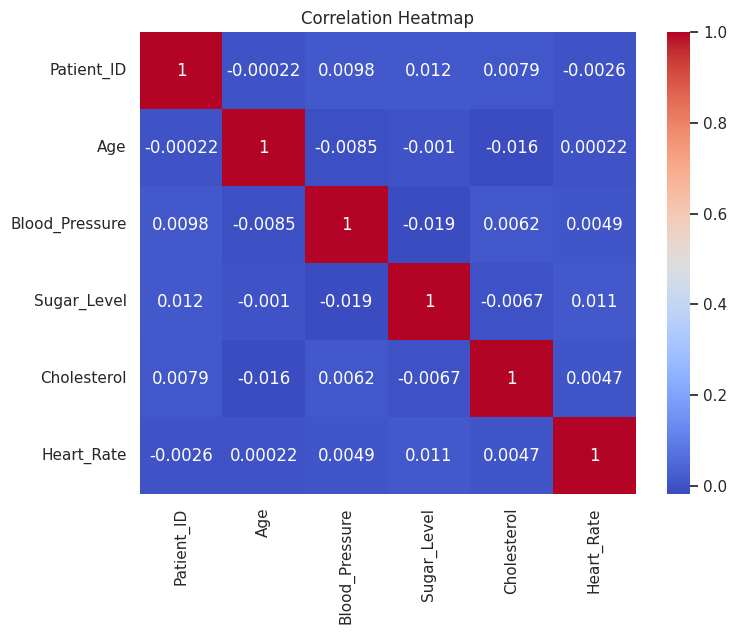

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [35]:
data.to_csv("healthcare_data.csv", index=False)